In [1]:
# Reinforcement learning
# HW3
# Amir Gharghabi
# Q-Learning
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm, trange
from typing import Optional

In [2]:
def plot_result(total_reward_per_run, regret_per_run, num_episodes , num_runs, figsize = (15,4), title = '', color = 'blue'):

  fig, axs = plt.subplots(2, 1, figsize = figsize)

  # Total_reward
  axs[0].set_title('Reward')
  mean_total_reward_per_run = np.mean(np.array(total_reward_per_run), axis = 0)
  std_total_reward_per_run = np.std(np.array(total_reward_per_run), axis = 0)
  up_bound_total_reward = mean_total_reward_per_run + 1.96 * std_total_reward_per_run/np.sqrt(num_runs)
  low_bound_total_reward = mean_total_reward_per_run - 1.96 * std_total_reward_per_run/np.sqrt(num_runs)
  axs[0].plot(range(num_episodes), mean_total_reward_per_run, label = 'Total_Reward', color = color)
  axs[0].fill_between(range(num_episodes), low_bound_total_reward, up_bound_total_reward, alpha = 0.5, color = color)
# axs[0].set_xlabel('episode')
  axs[0].set_ylabel('Total Reward')
  
  

  # Regret
  axs[1].set_title('Regret')
  mean_regret_per_run = np.mean(np.array(regret_per_run), axis = 0)
  std_regret_per_run = np.std(np.array(regret_per_run), axis = 0)
  up_bound_regret = mean_regret_per_run + 1.96 * std_regret_per_run/np.sqrt(num_runs)
  low_bound_regret = mean_regret_per_run - 1.96 * std_regret_per_run/np.sqrt(num_runs)
  axs[1].plot(range(num_episodes), mean_regret_per_run, label = 'Regret', color = color)
  axs[1].fill_between(range(num_episodes),low_bound_regret, up_bound_regret, alpha = 0.5, color = color)
  # axs[1].set_xlabel('episode')
  axs[1].set_ylabel('Regret')

  # plt.ylabel('Reward')
  fig.suptitle(title)
  plt.xlabel('episode')
  plt.legend()
  plt.show()






In [3]:
def compare_result(total_reward_per_run_1, total_reward_per_run_2,
                   regret_per_run_1, regret_per_run_2,
                   num_episodes , num_runs, figsize = (15,4), title = '',
                   lable1='', lable2=''):

  fig, axs = plt.subplots(2, 1, figsize = figsize)

  # Total_reward
  axs[0].set_title('Reward')
  mean_total_reward_per_run_1 = np.mean(np.array(total_reward_per_run_1), axis = 0)
  std_total_reward_per_run_1 = np.std(np.array(total_reward_per_run_1), axis = 0)
  up_bound_total_reward_1 = mean_total_reward_per_run_1 + 1.96 * std_total_reward_per_run_1/np.sqrt(num_runs)
  low_bound_total_reward_1 = mean_total_reward_per_run_1 - 1.96 * std_total_reward_per_run_1/np.sqrt(num_runs)
  mean_total_reward_per_run_2 = np.mean(np.array(total_reward_per_run_2), axis = 0)
  std_total_reward_per_run_2 = np.std(np.array(total_reward_per_run_2), axis = 0)
  up_bound_total_reward_2 = mean_total_reward_per_run_2 + 1.96 * std_total_reward_per_run_2/np.sqrt(num_runs)
  low_bound_total_reward_2 = mean_total_reward_per_run_2 - 1.96 * std_total_reward_per_run_2/np.sqrt(num_runs)
  
  axs[0].plot(range(num_episodes), mean_total_reward_per_run_1, label = lable1, color = 'blue')
  axs[0].fill_between(range(num_episodes), low_bound_total_reward_1, up_bound_total_reward_1, alpha = 0.5, color = 'blue')
  axs[0].plot(range(num_episodes), mean_total_reward_per_run_2, label = lable2, color = 'red')
  axs[0].fill_between(range(num_episodes), low_bound_total_reward_2, up_bound_total_reward_2, alpha = 0.5, color = 'red')
# axs[0].set_xlabel('episode')
  axs[0].set_ylabel('Total Reward')
  
  

  # Regret
  axs[1].set_title('Regret')
  mean_regret_per_run_1 = np.mean(np.array(regret_per_run_1), axis = 0)
  std_regret_per_run_1 = np.std(np.array(regret_per_run_1), axis = 0)
  up_bound_regret_1 = mean_regret_per_run_1 + 1.96 * std_regret_per_run_1/np.sqrt(num_runs)
  low_bound_regret_1 = mean_regret_per_run_1 - 1.96 * std_regret_per_run_1/np.sqrt(num_runs)
  mean_regret_per_run_2 = np.mean(np.array(regret_per_run_2), axis = 0)
  std_regret_per_run_2 = np.std(np.array(regret_per_run_2), axis = 0)
  up_bound_regret_2 = mean_regret_per_run_2 + 1.96 * std_regret_per_run_2/np.sqrt(num_runs)
  low_bound_regret_2 = mean_regret_per_run_2 - 1.96 * std_regret_per_run_2/np.sqrt(num_runs)

  axs[1].plot(range(num_episodes), mean_regret_per_run_1, label = lable1)
  axs[1].fill_between(range(num_episodes),low_bound_regret_1, up_bound_regret_1, alpha = 0.5)
  axs[1].plot(range(num_episodes), mean_regret_per_run_2, label = lable2, color='red')
  axs[1].fill_between(range(num_episodes),low_bound_regret_2, up_bound_regret_2, alpha = 0.5,color='red')
  axs[1].set_ylabel('Regret')

  fig.suptitle(title)
  plt.xlabel('episode')
  plt.legend()
  plt.show()



In [4]:
def cumulative_regret(regret_per_run):
  # Calculate the cumulative sum for each inner list separately
  cumulative_regret_per_run = []
  for inner_list in regret_per_run:
      cumulative_sum = 0
      cumulative_regret = []
      for value in inner_list:
          cumulative_sum += value
          cumulative_regret.append(cumulative_sum)
      cumulative_regret_per_run.append(cumulative_regret)
  return cumulative_regret_per_run

In [5]:
class QLearning:

  def __init__(self, env, learning_rate=0.1, learning_rate_decay=0.99,discount=0.99, epsilon=1, epsilon_decay=0.99):

    self.env = env
    self.state_size = env.observation_space.n
    self.action_space = env.action_space
    self.action_size = env.action_space.n
    self.q_table = np.zeros((self.state_size, self.action_size))

    self.learning_rate = learning_rate
    self.initial_learning_rate = learning_rate
    self.learning_rate_decay = learning_rate_decay
    self.discount = discount
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay


  def get_action(self, state):
    if np.random.rand() < self.epsilon:
      return self.env.action_space.sample()
    else:
      return np.argmax(self.q_table[state])

  def train(self, episodes):

    regrets = []
    total_rewards = []
    frames = []

    for episode in range(episodes):
      # if episode == 400:
      #   print()
      # elif episode == 980:
      #   print()
      self.learning_rate = self.initial_learning_rate
      state, _ = self.env.reset()
      total_reward = 0
      number_actions_taken = 0
      stuck = False
      while True:
        number_actions_taken += 1
        self.learning_rate *= self.learning_rate_decay
        action = self.get_action(state)
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        # if terminated:
        #   print()
        # if reward == -100:
        #   truncated = True
        current_q = self.q_table[state, action]
        next_max_q = np.max(self.q_table[next_state])

        # Write Q-Learning updating rule
        new_q = current_q + self.learning_rate*(reward + self.discount * next_max_q - current_q)
        self.q_table[state , action] = new_q

        total_reward += reward
        state = next_state

        if episode == episodes-1:
          frames.append(self.env.render())
        
        unknown = number_actions_taken < -total_reward
        # unknown = total_reward < - 1000
        # if unknown:
        #   print()
        
        stuck = (number_actions_taken > 5000)
        # if stuck:
        #   print()
        if terminated or truncated or stuck:
          # Calcualte regret
          max_reward = -13
          regret = max_reward - total_reward
          # if total_reward > -30:
          #   print()
          regrets.append(regret)
          total_rewards.append(total_reward)
          break

      if (self.epsilon_decay):
        self.epsilon = max(0.01, self.epsilon_decay * self.epsilon )

    return regrets, total_rewards, frames


In [6]:
env = gym.make('CliffWalking-v0', is_slippery=False)


In [10]:
num_runs = 5
num_episodes = 1000

learning_rate = 0.1


discount = 0.9
epsilon = 1
# epsilon = 0.1
epsilon_decay = 0.5
# epsilon_decay = 1



Running:   0%|          | 0/5 [00:00<?, ?it/s]

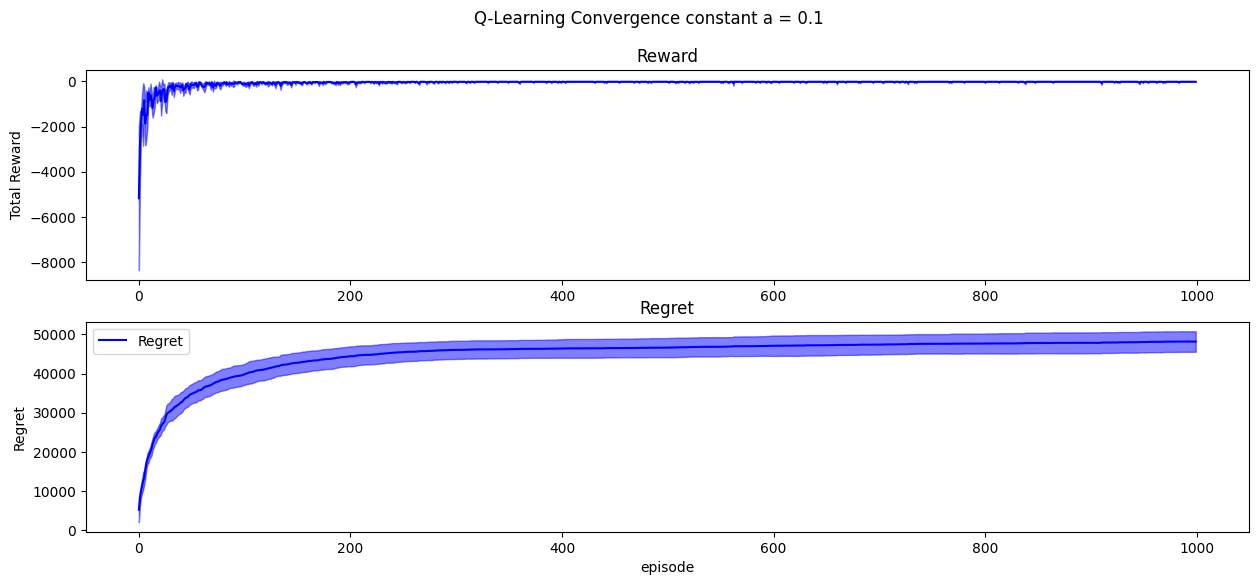

In [11]:
learning_rate_decay = 1
#___________________Constant Alpha=0.1 ________________________#

regret_per_run_const_a = []
total_reward_per_run_const_a =[]
for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = QLearning(env, learning_rate, learning_rate_decay, discount, epsilon_decay)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_const_a.append(regret)
  total_reward_per_run_const_a.append(total_reward)
  
cumulative_regret_per_run_const_a = cumulative_regret(regret_per_run_const_a)

plot_result(total_reward_per_run_const_a, cumulative_regret_per_run_const_a, num_episodes , num_runs,
              figsize = (15, 6), title = 'Q-Learning Convergence constant a = 0.1', color='blue')


Running:   0%|          | 0/5 [00:00<?, ?it/s]

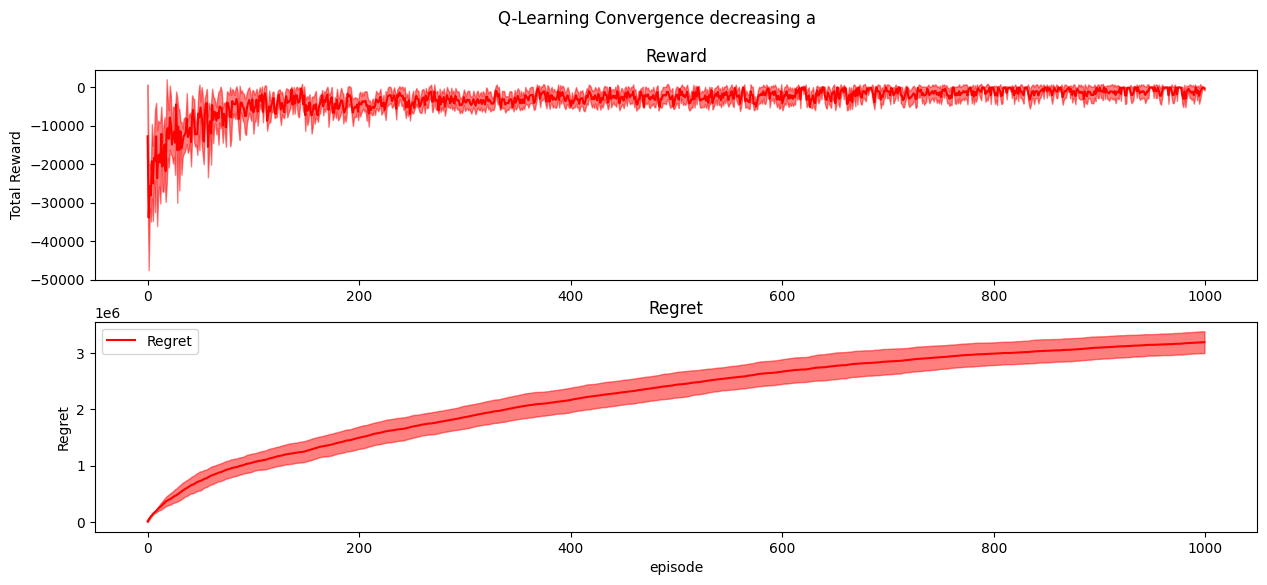

In [12]:
learning_rate_decay = 0.9
# learning_rate_decay = 0.99

#___________________Variable Alpha ________________________#

regret_per_run_var_a = []
total_reward_per_run_var_a =[]
for _ in tqdm(range(num_runs), desc = 'Running'):
  env.reset()
  agent = QLearning(env, learning_rate, learning_rate_decay, discount, epsilon_decay)
  regret, total_reward, frames = agent.train(num_episodes)

  regret_per_run_var_a.append(regret)
  total_reward_per_run_var_a.append(total_reward)
  
cumulative_regret_per_run_var_a = cumulative_regret(regret_per_run_var_a)

plot_result(total_reward_per_run_var_a, cumulative_regret_per_run_var_a, num_episodes , num_runs,
              figsize = (15, 6), title = 'Q-Learning Convergence decreasing a', color='red')


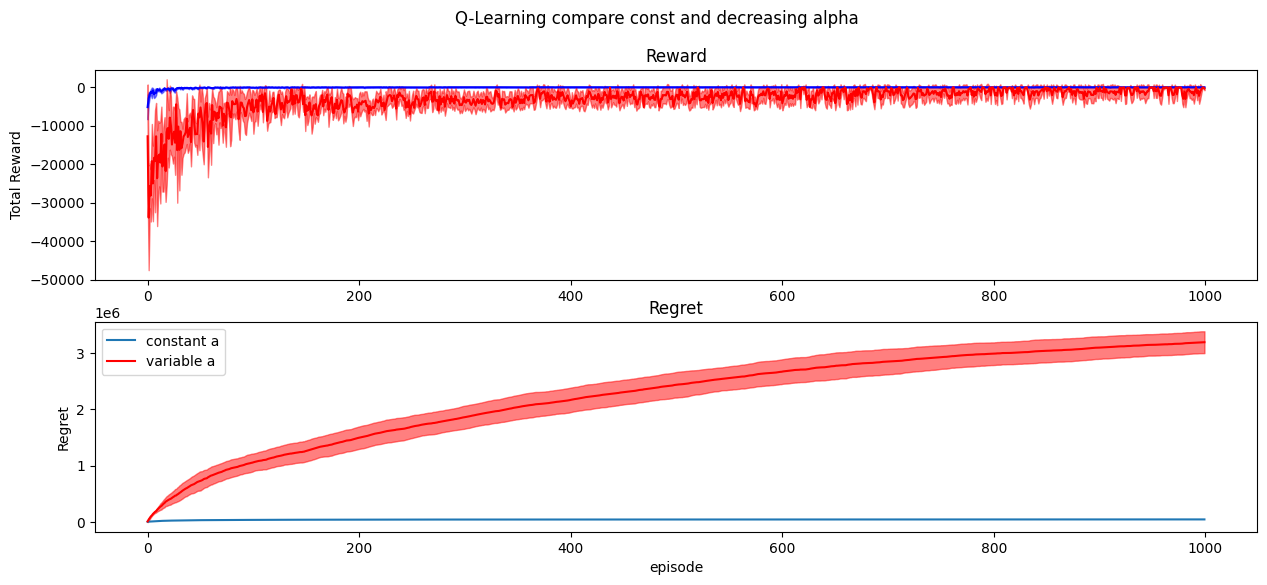

In [13]:
compare_result(total_reward_per_run_const_a, total_reward_per_run_var_a,
               cumulative_regret_per_run_const_a, cumulative_regret_per_run_var_a,
                num_episodes , num_runs,
              figsize = (15, 6), title = 'Q-Learning compare const and decreasing alpha', lable1='constant a', lable2='variable a')